<a href="https://colab.research.google.com/github/postnicov/ResazurinResorufin/blob/main/KubelkaMunk_ColorAnalysis_v2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kubelka-Munk Spectral Reflectance and Color Analysis

**Version 2.2 - 2026-08-07**

This Google Colab notebook reads a normalized resazurin/resorufin absorbance spectrum, smooths the low-signal region, calculates simplified Kubelka-Munk reflectance, optimizes the S0 scattering constant against a user-defined CIE Lab triplet, and reports CIE XYZ, CIE Lab, sRGB, and Munsell notation.

For wavelengths above 650 nm, the source absorbance is near the baseline/noise floor and contains spikes and baseline shifts. Because the nonlinear reflectance transform magnifies small low-absorbance changes, the notebook applies a median filter and then a Savitzky-Golay filter to absorbance before converting it to reflectance. The raw and processed results are shown together.

In [8]:
#@title Install and Import Required Packages
import importlib, subprocess, sys
required = {'numpy':'numpy', 'pandas':'pandas', 'matplotlib':'matplotlib', 'scipy':'scipy', 'colour-science':'colour'}
for package, module in required.items():
    try:
        importlib.import_module(module)
        print(f'{package} already installed.')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter
import colour
from colour import SpectralDistribution, MSDS_CMFS, SDS_ILLUMINANTS, XYZ_to_Lab, XYZ_to_sRGB
import re
print('colour-science version:', colour.__version__)

numpy already installed.
pandas already installed.
matplotlib already installed.
scipy already installed.
colour-science already installed.
colour-science version: 0.4.7


In [9]:
#@title Set Reference CIE Lab Triplet
reference_L_star = 70.65 #@param {type:'number'}
reference_a_star = 27.25 #@param {type:'number'}
reference_b_star = -32.97 #@param {type:'number'}
target_Lab = np.array([reference_L_star, reference_a_star, reference_b_star], dtype=float)
print(f'Reference Lab: L*={target_Lab[0]:.4f}, a*={target_Lab[1]:.4f}, b*={target_Lab[2]:.4f}')

Reference Lab: L*=70.6500, a*=27.2500, b*=-32.9700


In [10]:
#@title Set Global Plot Appearance
plot_font_size = 12 #@param {type:'integer'}
plot_font_family = 'serif' #@param ['serif', 'sans-serif', 'monospace']
plot_line_width = 1.0 #@param {type:'number'}
plt.rcParams.update({'font.size':plot_font_size, 'font.family':plot_font_family, 'lines.linewidth':plot_line_width, 'axes.labelsize':plot_font_size, 'axes.titlesize':plot_font_size, 'legend.fontsize':plot_font_size, 'xtick.labelsize':plot_font_size, 'ytick.labelsize':plot_font_size})
print(f'Font: {plot_font_family}; font size: {plot_font_size}; default line width: {plot_line_width}')

Font: serif; font size: 12; default line width: 1.0


Loaded 441 points: 360 to 800 nm


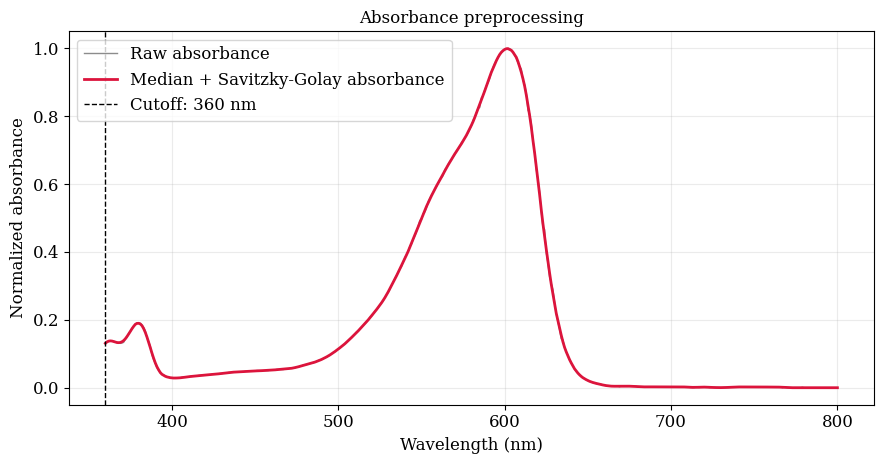

In [11]:
#@title Load and Smooth the Absorbance Spectrum
url = 'https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/Rz7Ref.csv'
df = pd.read_csv(url).dropna().sort_values('lambda').reset_index(drop=True)
wavelengths = df['lambda'].to_numpy(dtype=float)
absorbance_raw = df['Absorbance'].to_numpy(dtype=float)
print(f'Loaded {len(wavelengths)} points: {wavelengths.min():.0f} to {wavelengths.max():.0f} nm')
smoothing_cutoff_nm = 360 #@param {type:'number'}
median_window = 5 #@param {type:'integer'}
savgol_window = 15 #@param {type:'integer'}
savgol_polynomial_order = 3 #@param {type:'integer'}
if median_window < 3 or median_window % 2 == 0:
    raise ValueError('median_window must be odd and at least 3.')
if savgol_window % 2 == 0 or savgol_window <= savgol_polynomial_order:
    raise ValueError('savgol_window must be odd and greater than polynomial order.')
tail = wavelengths >= smoothing_cutoff_nm
if savgol_window > np.count_nonzero(tail):
    raise ValueError('savgol_window is longer than the selected tail.')
tail_median = median_filter(absorbance_raw[tail], size=median_window, mode='nearest')
tail_smooth = savgol_filter(tail_median, savgol_window, savgol_polynomial_order, mode='interp')
absorbance_smooth = absorbance_raw.copy()
absorbance_smooth[tail] = np.clip(tail_smooth, 0, None)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, absorbance_raw, color='0.55', label='Raw absorbance')
ax.plot(wavelengths[tail], absorbance_smooth[tail], color='crimson', lw=2*plot_line_width, label='Median + Savitzky-Golay absorbance')
ax.axvline(smoothing_cutoff_nm, color='black', ls='--', label=f'Cutoff: {smoothing_cutoff_nm} nm')
ax.set(xlabel='Wavelength (nm)', ylabel='Normalized absorbance', title='Absorbance preprocessing')
ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()

In [12]:
#@title Define Colorimetric Functions and Optimize S0
def kubelka_munk_reflectance(A, S0):
    if S0 <= 0:
        raise ValueError('S0 must be positive.')
    x = np.clip(np.asarray(A, dtype=float), 0, None) / S0
    return np.clip(1 + x - np.sqrt(x**2 + 2*x), 0, 1)
cmfs = MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
illuminant_D65 = SDS_ILLUMINANTS['D65']
D65_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']
def reflectance_to_XYZ(reflectance):
    sd = SpectralDistribution(dict(zip(wavelengths, reflectance)), name='Reflectance')
    return colour.sd_to_XYZ(sd.align(cmfs.shape), cmfs=cmfs, illuminant=illuminant_D65)
def XYZ_to_Lab_D65(XYZ):
    return XYZ_to_Lab(XYZ / 100, illuminant=D65_xy)
def lab_error(S0):
    R = kubelka_munk_reflectance(absorbance_smooth, S0)
    return np.sum((XYZ_to_Lab_D65(reflectance_to_XYZ(R)) - target_Lab)**2)
result = minimize_scalar(lab_error, bounds=(1e-4, 50), method='bounded', options={'xatol':1e-8})
S0_opt = result.x
R_raw = kubelka_munk_reflectance(absorbance_raw, S0_opt)
R_opt = kubelka_munk_reflectance(absorbance_smooth, S0_opt)
XYZ_opt = reflectance_to_XYZ(R_opt)
Lab_opt = XYZ_to_Lab_D65(XYZ_opt)
RGB_opt = np.clip(XYZ_to_sRGB(XYZ_opt / 100, illuminant=D65_xy), 0, 1)
print(f'Optimized S0 = {S0_opt:.6f}')
print(f'XYZ = ({XYZ_opt[0]:.4f}, {XYZ_opt[1]:.4f}, {XYZ_opt[2]:.4f})')
print(f'Lab = ({Lab_opt[0]:.4f}, {Lab_opt[1]:.4f}, {Lab_opt[2]:.4f})')
print(f'sRGB = ({RGB_opt[0]:.4f}, {RGB_opt[1]:.4f}, {RGB_opt[2]:.4f})')

Optimized S0 = 0.481870
XYZ = (32.8826, 31.2888, 67.9358)
Lab = (62.7506, 11.5637, -35.1115)
sRGB = (0.5330, 0.5807, 0.8393)


In [13]:
#@title Calculate Munsell Code Rounded to 0.5
# Munsell renotation data are referenced to Illuminant C.
# The color estimated under D65 is adapted to Illuminant C before notation conversion.
C_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['C']
XYZ_w_D65 = colour.xy_to_XYZ(D65_xy)
XYZ_w_C = colour.xy_to_XYZ(C_xy)
XYZ_C = colour.chromatic_adaptation(XYZ_opt / 100.0, XYZ_w_D65, XYZ_w_C, method='Von Kries')
xyY_C = colour.XYZ_to_xyY(XYZ_C)
munsell_unrounded = str(colour.xyY_to_munsell_colour(xyY_C, hue_decimals=3, value_decimals=3, chroma_decimals=3))
def round_to_half(x):
    return np.floor(float(x) * 2.0 + 0.5) / 2.0
def compact_half(x):
    x = round_to_half(x)
    return str(int(x)) if x.is_integer() else f'{x:.1f}'
chromatic = re.fullmatch(r'\s*([0-9]+(?:\.[0-9]+)?)([A-Z]+)\s+([0-9]+(?:\.[0-9]+)?)/([0-9]+(?:\.[0-9]+)?)\s*', munsell_unrounded)
neutral = re.fullmatch(r'\s*N([0-9]+(?:\.[0-9]+)?)\s*', munsell_unrounded)
if chromatic:
    hue, hue_letter, value, chroma = chromatic.groups()
    munsell_code_0_5 = f'{compact_half(hue)}{hue_letter} {compact_half(value)}/{compact_half(chroma)}'
elif neutral:
    munsell_code_0_5 = f'N{compact_half(neutral.group(1))}'
else:
    raise ValueError(f'Unexpected Munsell notation: {munsell_unrounded!r}')
print('Munsell notation before rounding:', munsell_unrounded)
print('Munsell notation rounded to 0.5:', munsell_code_0_5)

Munsell notation before rounding: 7.807PB 6.190/9.114
Munsell notation rounded to 0.5: 8PB 6/9


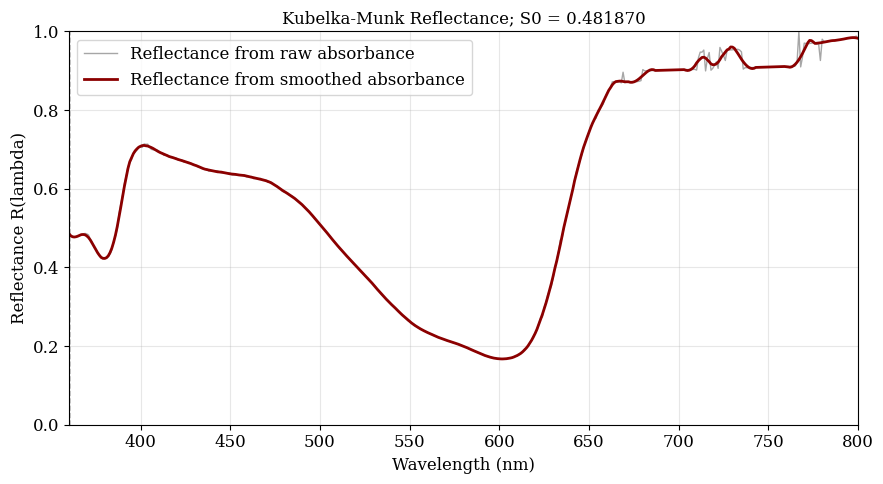

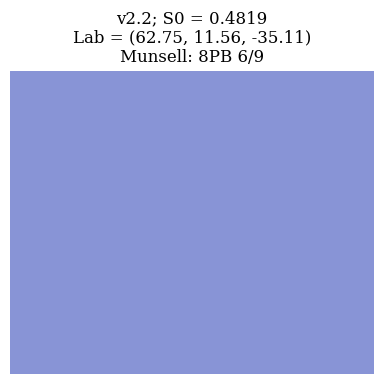

In [14]:
#@title Plot Reflectance and Perceived Color
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wavelengths, R_raw, color='0.65', label='Reflectance from raw absorbance')
ax.plot(wavelengths, R_opt, color='darkred', lw=2*plot_line_width, label='Reflectance from smoothed absorbance')
ax.axvline(smoothing_cutoff_nm, color='black', ls='--')
ax.set(xlabel='Wavelength (nm)', ylabel='Reflectance R(lambda)', title=f'Kubelka-Munk Reflectance; S0 = {S0_opt:.6f}', xlim=(wavelengths.min(), wavelengths.max()), ylim=(0, 1))
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(4, 4))
ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=RGB_opt))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title(f'v2.2; S0 = {S0_opt:.4f}\nLab = ({Lab_opt[0]:.2f}, {Lab_opt[1]:.2f}, {Lab_opt[2]:.2f})\nMunsell: {munsell_code_0_5}', fontsize=plot_font_size)
plt.tight_layout(); plt.show()